In [ ]:
import requests
headers = {'User-Agent' : 'myapp'}
endpoint = 'https://api.weather.gov/gridpoints/LWX/116,84/forecast'

response = requests.get(endpoint, headers = headers)
data = response.json()


{'@context': ['https://geojson.org/geojson-ld/geojson-context.jsonld', {'@version': '1.1', 'wx': 'https://api.weather.gov/ontology#', 'geo': 'http://www.opengis.net/ont/geosparql#', 'unit': 'http://codes.wmo.int/common/unit/', '@vocab': 'https://api.weather.gov/ontology#'}], 'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[-76.4266, 39.1045], [-76.4228, 39.1264], [-76.451, 39.1294], [-76.4549, 39.1075], [-76.4266, 39.1045]]]}, 'properties': {'units': 'us', 'forecastGenerator': 'BaselineForecastGenerator', 'generatedAt': '2026-06-22T21:00:49+00:00', 'updateTime': '2026-06-22T20:53:21+00:00', 'validTimes': '2026-06-22T14:00:00+00:00/P7DT11H', 'elevation': {'unitCode': 'wmoUnit:m', 'value': 0.9144}, 'periods': [{'number': 1, 'name': 'This Afternoon', 'startTime': '2026-06-22T17:00:00-04:00', 'endTime': '2026-06-22T18:00:00-04:00', 'isDaytime': True, 'temperature': 92, 'temperatureUnit': 'F', 'temperatureTrend': None, 'probabilityOfPrecipitation': {'unitCode': 'wmoUnit:

In [12]:
# `features` contains the data we want.
todaysweather = data['properties']['periods'][0]
print(todaysweather['temperature'], "Degrees") 
print(todaysweather['probabilityOfPrecipitation']['value'], "% chance of rain") 
print("Wind is at", todaysweather['windSpeed']) 
print(todaysweather['shortForecast']) 
print(todaysweather['detailedForecast']) 



92 Degrees
79 % chance of rain
Wind is at 15 mph
Showers And Thunderstorms
Showers and thunderstorms. Some of the storms could be severe and produce heavy rain. Cloudy, with a high near 92. South wind around 15 mph, with gusts as high as 21 mph. Chance of precipitation is 80%. New rainfall amounts between 1 and 2 inches possible.


In [1]:
import requests
from PIL import Image

url = 'https://www.pngall.com/wp-content/uploads/17/Sunshine-Design-Emoji-PNG-thumb.png'

# This statement requests the resource at
# the given link, extracts its contents
# and saves it in a variable
data = requests.get(url).content

# Opening a new file named img with extension .jpg
# This file would store the data of the image file
f = open('img.jpg','wb')

# Storing the image data inside the data variable to the file
f.write(data)
f.close()

# Opening the saved image and displaying it
img = Image.open('img.jpg')
img.show()

In [ ]:
import requests
from PIL import Image

url = 'https://images.emojiterra.com/google/noto-emoji/unicode-16.0/bw/1024px/2600.png'

# This statement requests the resource at
# the given link, extracts its contents
# and saves it in a variable
data = requests.get(url).content

# Opening a new file named img with extension .jpg
# This file would store the data of the image file
f = open('img.jpg','wb')

from escpos.printer import Network
kitchen = Network("192.168.50.102", profile="TM-T88V") 

f.write(data)
f.close()

kitchen.image(img)
kitchen.cut()



Showers And Thunderstorms then Chance Showers And Thunderstorms


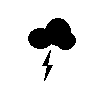

In [32]:
from PIL import Image, ImageDraw

###############################################################################
# Weather icon generator - draws simple monochrome icons, no fonts needed
###############################################################################
def make_icon(kind, size=100):
    img = Image.new("1", (size, size), 1)  # 1-bit image, white background
    d = ImageDraw.Draw(img)
    cx, cy = size // 2, size // 2

    if kind == "sunny":
        r = size // 5
        d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=0)
        for angle in range(0, 360, 45):
            import math
            x1 = cx + (r + 4) * math.cos(math.radians(angle))
            y1 = cy + (r + 4) * math.sin(math.radians(angle))
            x2 = cx + (r + 14) * math.cos(math.radians(angle))
            y2 = cy + (r + 14) * math.sin(math.radians(angle))
            d.line([x1, y1, x2, y2], fill=0, width=3)

    elif kind == "cloudy":
        d.ellipse([cx - 22, cy - 5, cx + 2, cy + 15], fill=0)
        d.ellipse([cx - 5, cy - 15, cx + 20, cy + 12], fill=0)
        d.ellipse([cx + 5, cy - 2, cx + 25, cy + 16], fill=0)

    elif kind == "rain" or kind == "showers":
        d.ellipse([cx - 22, cy - 18, cx + 2, cy + 2], fill=0)
        d.ellipse([cx - 5, cy - 28, cx + 20, cy - 1], fill=0)
        d.ellipse([cx + 5, cy - 15, cx + 25, cy + 3], fill=0)
        for dx in (-15, 0, 15):
            d.line([cx + dx, cy + 10, cx + dx - 5, cy + 25], fill=0, width=3)

    elif kind == "snow":
        d.ellipse([cx - 22, cy - 18, cx + 2, cy + 2], fill=0)
        d.ellipse([cx - 5, cy - 28, cx + 20, cy - 1], fill=0)
        d.ellipse([cx + 5, cy - 15, cx + 25, cy + 3], fill=0)
        for dx in (-15, 0, 15):
            d.ellipse([cx + dx - 2, cy + 18, cx + dx + 2, cy + 22], fill=0)

    elif kind == "thunderstorms":
        d.ellipse([cx - 22, cy - 22, cx + 2, cy - 2], fill=0)
        d.ellipse([cx - 5, cy - 32, cx + 20, cy - 5], fill=0)
        d.ellipse([cx + 5, cy - 19, cx + 25, cy - 1], fill=0)
        d.polygon([(cx, cy), (cx - 8, cy + 15), (cx + 2, cy + 15), (cx - 6, cy + 30)], fill=0)

    return img

###############################################################################
# Print a weather line: icon + label
###############################################################################

import requests
headers = {'User-Agent' : 'myapp'}
endpoint = 'https://api.weather.gov/gridpoints/LWX/116,84/forecast'

response = requests.get(endpoint, headers = headers)
data = response.json()

todaysweather = data['properties']['periods'][0]
print(todaysweather['shortForecast']) 

if "cloudy" in todaysweather['shortForecast'].lower():
    icon = make_icon("cloudy")
elif "sunny" in todaysweather['shortForecast'].lower():
    icon = make_icon("sunny")
elif "thunderstorm" in todaysweather['shortForecast'].lower():
    icon = make_icon("thunderstorms")
elif "showers" in todaysweather['shortForecast'].lower() or "rain" in todaysweather['shortForecast'].lower():
    icon = make_icon("rain")
elif "snow" in todaysweather['shortForecast'].lower():
    icon = make_icon("snow")
    
if icon:
    display(icon) 